# Multiple Choice Question Evaluation for Zeolite Synthesis (GreenandNew_90 Question Bank)

**Llama-3-8B-Instruct + GPT-4.1 Evaluation**

This notebook evaluates LLM performance on multiple-choice questions about zeolite synthesis
using the **QuestionBank_GreenandNew_90.xlsx** dataset with 3 question categories.

**Question Categories (90 total):**
- Synthesis (30 questions)
- Chem Con & Catalysis (30 questions)
- Envir. Apps (DAC) (30 questions)

**Models:**
- Llama-3-8B-Instruct (GPU 3) — all methods
- GPT-4.1 (OpenAI API) — no_context baseline only

**Configuration:**
- k=10 and k=15
- 7 retrieval methods: Abstract baseline, No context (Llama), No context (GPT-4.1), FAISS, MMR, BM25, Hybrid
- Accuracy reported **per category** and **overall**
- All plots saved as **SVG** files

**Structure:**
- Phase 1: Abstract, No Context (Llama), No Context (GPT-4.1), FAISS (with intermediate results plot)
- Phase 2: MMR, BM25, Hybrid (with full results plot)
- Phase 3: k=15 for all retrieval methods

Run with kernel v6 instead of v7

In [1]:
# Core imports
import os
# # OOM Fix: limit max split size to reduce GPU memory fragmentation (PyTorch 1.12 compatible)
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:256"

import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import gc

# LangChain (for retrieval only) and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, pipeline

# OpenAI (for GPT-4.1 no_context baseline)
from openai import OpenAI
import httpx

# Load environment variables (HF_TOKEN, OPENAI_API_TOKEN)
# !source runs in a subprocess; parse env.sh directly
with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            key, val = line[len('export '):].split('=', 1)
            os.environ[key] = val.strip('"').strip("'")

hf_token = os.environ.get("HF_TOKEN")

openai_key = os.environ.get("OPENAI_API_TOKEN")
if not openai_key:
    raise ValueError("OPENAI_API_TOKEN not found. Add it to /home/jupyter/Mrigi/env.sh.")
openai_client = OpenAI(api_key=openai_key, http_client=httpx.Client())
print("✓ OpenAI client initialized (for GPT-4.1 no_context baseline)")

✓ OpenAI client initialized (for GPT-4.1 no_context baseline)


In [2]:
!nvidia-smi

Fri Mar  6 11:02:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   32C    P0             64W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   1  NVIDIA RTX A5000               Off |   00000000:4B:00.0 Off |                  Off |
| 30%   31C    P0             61W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   2  NVIDIA RTX A5000               Off |   00000000:B1:00.0 Off |                  Off |
| 30%   31C    P0             59W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |            

In [3]:
!kill -9 700408

/bin/bash: line 0: kill: (700408) - No such process


In [4]:
# Model Configuration
MODELS = {
    'llama': {
        'name': 'meta-llama/Meta-Llama-3-8B-Instruct',
        'display_name': 'Llama-3-8B-Instruct',
        'gpu': 'cuda:3'
    }
}

K_VALUES = [10]
METHODS = ['abstract', 'no_context', 'no_context_gpt41', 'faiss', 'mmr', 'bm25', 'hybrid']

def load_model(model_key):
    """
    Load a model on a specific GPU.
    
    Args:
        model_key: Key from MODELS dictionary
    
    Returns:
        tuple: (llm, model, tokenizer) - LangChain LLM and underlying components
    """
    config = MODELS[model_key]
    model_name = config['name']
    device = config['gpu']
    
    print(f"\n{'='*80}")
    print(f"Loading {config['display_name']} on {device}...")
    print(f"{'='*80}")
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        use_fast=True,
        token=hf_token
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map=device,
        trust_remote_code=True,
        torch_dtype=torch.float16,
        token=hf_token
    )
    
    # Set up generation config
    generation_config = GenerationConfig.from_pretrained(model_name)
    generation_config.max_new_tokens = 100
    generation_config.temperature = 0.1
    
    # Set up pipeline
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        generation_config=generation_config,
    )
    llm = HuggingFacePipeline(pipeline=pipe)
    
    print(f"✓ {config['display_name']} loaded successfully on {device}")
    print(f"  max_new_tokens=100, temperature=0.1, use_fast=True")
    
    return llm, model, tokenizer

def cleanup_model(model, tokenizer):
    """Clean up model from GPU memory."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("✓ GPU memory cleared")

print("✓ Model management functions defined")

✓ Model management functions defined


In [5]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. You may use the provided context to inform your answer as well as your own knowledge. 

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.
Context:
{context}

Question: {question}
"""

In [6]:
def extract_completion(full_response, tokenizer):
    """
    Extract the assistant's completion from the full response using Llama special tokens.
    Splits on the assistant header tag to isolate just the model's output.
    """
    assistant_tag = "<|start_header_id|>assistant<|end_header_id|>"
    if assistant_tag in full_response:
        completion = full_response.split(assistant_tag)[-1].strip()
    else:
        completion = full_response.strip()
    
    # Remove any end-of-text tokens
    for token in ["<|eot_id|>", "<|end_of_text|>"]:
        completion = completion.replace(token, "").strip()
    
    return completion

# def safe_inference(llm, formatted_prompt):
#     """Run inference under torch.inference_mode and aggressively clean up GPU memory after."""
#     try:
#         with torch.inference_mode():
#             result = llm(formatted_prompt)
#         return result
#     finally:
#         gc.collect()
#         torch.cuda.empty_cache()

def parse_mc_answer(completion):
    """
    Parse a multiple choice answer from the model's completion.
    Uses rfind to get the last 'Answer: ' occurrence (avoids matching the example).
    """
    last_answer_pos = completion.rfind("Answer: ")
    
    if last_answer_pos != -1:
        model_answer = completion[last_answer_pos + 8].upper()
        
        if model_answer in ['A', 'B', 'C', 'D', 'E']:
            explanation = ""
            answer_end = completion[last_answer_pos:].split('\n')[0]
            if '-' in answer_end:
                explanation = answer_end.split('-', 1)[1].strip()
            return model_answer, explanation
    
    return None, None

def evaluate_mc_response(llm, query, correct_answer, context, tokenizer):
    """Evaluate a single multiple choice question with context."""
    prompt_text = MC_PROMPT.format(context=context, question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using safe_inference (with inference_mode)
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'context': context,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        # No valid answer found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

def evaluate_mc_no_context(llm, query, correct_answer, tokenizer):
    """Evaluate a single multiple choice question WITHOUT context."""
    NO_CONTEXT_PROMPT = """You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.

Question: {question}"""
    
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    
    # Apply Llama chat template with user role
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    try:
        # Get model's answer using safe_inference (with inference_mode)
        full_response = llm(formatted_prompt)
        
        # Extract assistant completion using special tokens
        completion = extract_completion(full_response, tokenizer)
        
        # Parse the answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ Evaluation functions defined (with chat template + special token parsing)")

# --- GPT-4.1 No Context Evaluation ---
def evaluate_mc_no_context_gpt41(query, correct_answer):
    """Evaluate a single MC question WITHOUT context using GPT-4.1 via OpenAI API."""
    NO_CONTEXT_PROMPT = """You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E.

Question: {question}"""
    
    prompt_text = NO_CONTEXT_PROMPT.format(question=query)
    
    try:
        response = openai_client.chat.completions.create(
            model="gpt-4.1",
            messages=[{"role": "user", "content": prompt_text}],
            temperature=0.1,
            max_tokens=150
        )
        completion = response.choices[0].message.content.strip()
        
        # Parse the answer using existing parse_mc_answer
        model_answer, explanation = parse_mc_answer(completion)
        
        if model_answer is not None:
            return {
                'query': query,
                'model_answer': model_answer,
                'correct_answer': correct_answer,
                'is_correct': model_answer == correct_answer,
                'full_response': completion,
                'explanation': explanation or ""
            }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'full_response': completion,
            'error': "No valid answer found in response"
        }
        
    except Exception as e:
        print(f"GPT-4.1 error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"GPT-4.1 API error: {str(e)}"
        }

print("✓ GPT-4.1 no_context evaluation function defined")

✓ Evaluation functions defined (with chat template + special token parsing)
✓ GPT-4.1 no_context evaluation function defined


In [7]:
def get_faiss_context(query, k=10):
    """Retrieve context using FAISS similarity search."""
    results = vector_db.similarity_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_mmr_context(query, k=10):
    """Retrieve context using Maximum Marginal Relevance."""
    results = vector_db.max_marginal_relevance_search(query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

def get_bm25_context(query, k=10):
    """Retrieve context using BM25 retriever."""
    results = bm25_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_hybrid_context(query, k=10):
    """Retrieve context using hybrid (ensemble) retriever."""
    results = ensemble_retriever.get_relevant_documents(query)[:k]
    return "\n\n".join([doc.page_content for doc in results])

def get_optimized_context(query, llm, tokenizer, k=10):
    """Retrieve context using LLM-optimized retrieval."""
    # Apply chat template for the optimization prompt
    prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=query)
    messages = [{"role": "user", "content": prompt_text}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    # Get optimized query
    full_response = llm(formatted_prompt)
    optimized_query = extract_completion(full_response, tokenizer)
    
    # Clean up - take only first line
    optimized_query = optimized_query.split('\n')[0].strip()
    
    # Use optimized query for retrieval
    results = vector_db.similarity_search(optimized_query, k=k)
    return "\n\n".join([doc.page_content for doc in results])

# Unified evaluation function for all methods
def evaluate_method(llm, method_name, questions_df, tokenizer, k=10):
    """
    Evaluate a specific retrieval method.
    Clears GPU cache after each question to prevent OOM errors.
    
    Args:
        llm: LangChain LLM instance
        method_name: Name of the method ('abstract', 'no_context', 'faiss', etc.)
        questions_df: DataFrame with questions
        tokenizer: Tokenizer for applying chat template
        k: Number of documents to retrieve
    
    Returns:
        dict: Results with accuracy and detailed responses
    """
    results = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), 
                       desc=f"Evaluating {method_name} (k={k})"):
        query = row['Question']
        correct_answer = row['Correct_Answer']
        
        try:
            if method_name == 'abstract':
                context = row['Context']
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'no_context':
                result = evaluate_mc_no_context(llm, query, correct_answer, tokenizer)
            elif method_name == 'no_context_gpt41':
                result = evaluate_mc_no_context_gpt41(query, correct_answer)
            elif method_name == 'faiss':
                context = get_faiss_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'mmr':
                context = get_mmr_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'bm25':
                context = get_bm25_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'hybrid':
                context = get_hybrid_context(query, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            elif method_name == 'optimized':
                context = get_optimized_context(query, llm, tokenizer, k=k)
                result = evaluate_mc_response(llm, query, correct_answer, context, tokenizer)
            else:
                raise ValueError(f"Unknown method: {method_name}")
        except Exception as e:
            # Catch OOM and other runtime errors per-question
            print(f"  ⚠ Error on question: {str(e)[:100]}")
            result = {
                'query': query,
                'model_answer': 'ERROR',
                'correct_answer': correct_answer,
                'is_correct': False,
                'error': str(e)
            }
        
        results.append(result)
        
        # Clear GPU cache after each question to prevent OOM
        gc.collect()
        torch.cuda.empty_cache()
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get('is_correct', False))
    total = len(results)
    accuracy = (correct_count / total) * 100 if total > 0 else 0
    
    return {
        'method': method_name,
        'k': k,
        'accuracy': accuracy,
        'correct_count': correct_count,
        'total': total,
        'detailed_results': results
    }

print("✓ Retrieval and unified evaluation functions defined (with per-question cache clearing)")

✓ Retrieval and unified evaluation functions defined (with per-question cache clearing)


In [8]:
# Load the vector database and retrieval components
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
faiss_retriever = vector_db.as_retriever(search_kwargs={"k": 10})
print(f"\u2713 Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"\u2713 Initialized BM25 retriever with {len(all_docs)} documents")

/tmp/ipykernel_754287/2821454396.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents
✓ Initialized BM25 retriever with 1474439 documents


In [9]:
# Define hybrid search function
from langchain.retrievers import EnsembleRetriever

def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

# Create ensemble retriever for hybrid method
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever],
    weights=[0.5, 0.5]
)

print("\u2713 Hybrid search function and ensemble retriever defined")

✓ Hybrid search function and ensemble retriever defined


In [10]:
# Query optimizer prompt and function for LLM-optimized retrieval
OPTIMIZE_QUERY_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""

def optimize_query_for_mcq(question: str, llm, tokenizer) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    Uses chat template with special tokens for proper Llama formatting.
    """
    try:
        prompt_text = OPTIMIZE_QUERY_PROMPT.format(question=question)
        messages = [{"role": "user", "content": prompt_text}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        
        response = llm(formatted_prompt)
        completion = extract_completion(response, tokenizer)
        
        # Clean up - take only first line
        optimized_query = completion.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question

print("✓ Query optimizer prompt and function defined")

✓ Query optimizer prompt and function defined


In [ ]:
# Load the question dataset from QuestionBank_GreenandNew_90.xlsx (3 sheets)
QUESTION_FILE = 'QuestionBank_GreenandNew_90.xlsx'

SHEET_NAMES = [
    'Synthesis',
    'Chem Con & Catalysis',
    'Envir. Apps (DAC)'
]

# Short labels for plots and results keys
CATEGORY_LABELS = {
    'Synthesis': 'Synthesis',
    'Chem Con & Catalysis': 'ChemCon',
    'Envir. Apps (DAC)': 'DAC'
}

# Load each sheet into a dict of DataFrames
category_dfs = {}
for sheet in SHEET_NAMES:
    df = pd.read_excel(QUESTION_FILE, sheet_name=sheet)
    df = df.dropna(subset=['gpt_generated_question'])
    df = df.rename(columns={
        'gpt_generated_question': 'Question',
        'gpt_generated_answer': 'Correct_Answer',
        'abstract': 'Context'
    })
    df['Correct_Answer'] = df['Correct_Answer'].str.strip().str.upper()
    label = CATEGORY_LABELS[sheet]
    category_dfs[label] = df
    print(f"✓ {label}: {len(df)} questions loaded")

# Also create a combined DataFrame for overall accuracy
mc_questions_all = pd.concat(category_dfs.values(), ignore_index=True)
print(f"\n✓ Total: {len(mc_questions_all)} questions across {len(SHEET_NAMES)} categories")
print(f"✓ Categories: {list(category_dfs.keys())}")

## Phase 1: Abstract, No Context (Llama + GPT-4.1), and FAISS

Run the first four methods and generate an intermediate results plot.

In [12]:
# Initialize results storage and load model
# Results structure: all_results[model][k_label][category][method] = {accuracy, correct_count, total, detailed_results}
all_results = {}
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Load Llama model
llm, model, tokenizer = load_model('llama')
model_display_name = MODELS['llama']['display_name']
all_results[model_display_name] = {}

# Phase 1 methods
phase1_methods = ['abstract', 'no_context', 'no_context_gpt41', 'faiss']
ALL_CATEGORIES = list(category_dfs.keys())  # ['Synthesis', 'ChemCon', 'DAC']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 1 experiments with k={k}")
    print(f"{'='*80}")
    
    if f"k={k}" not in all_results[model_display_name]:
        all_results[model_display_name][f"k={k}"] = {}
    
    for category in ALL_CATEGORIES:
        if category not in all_results[model_display_name][f"k={k}"]:
            all_results[model_display_name][f"k={k}"][category] = {}
        
        questions_df = category_dfs[category]
        
        for method in phase1_methods:
            print(f"\n--- {category} | {method.upper()} | k={k} ({len(questions_df)} questions) ---")
            
            try:
                result = evaluate_method(llm, method, questions_df, tokenizer, k=k)
                all_results[model_display_name][f"k={k}"][category][method] = result
                
                print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
                
            except Exception as e:
                print(f"✗ Error: {str(e)}")
                all_results[model_display_name][f"k={k}"][category][method] = {
                    'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
                }
    
    # Save intermediate results (WITH detailed_results for downstream use)
    temp_save_path = f'results_23e_complete_{timestamp}.json'
    with open(temp_save_path, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
    print(f"✓ Intermediate results saved to: {temp_save_path} ({os.path.getsize(temp_save_path)/(1024*1024):.1f} MB)")

print(f"\n{'='*80}")
print(f"Phase 1 complete!")
print(f"{'='*80}")


Loading Llama-3-8B-Instruct on cuda:3...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/utils/hub.py:374: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/tmp/ipykernel_754287/2908786605.py:59: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


✓ Llama-3-8B-Instruct loaded successfully on cuda:3
  max_new_tokens=100, temperature=0.1, use_fast=True

Running Phase 1 experiments with k=10

--- Synthesis | ABSTRACT | k=10 (30 questions) ---


...

✓ 96.67% (29/30)

--- DAC | NO_CONTEXT_GPT41 | k=10 (30 questions) ---


Evaluating no_context_gpt41 (k=10): 100%|██████████| 30/30 [01:44<00:00,  3.48s/it]


✓ 100.00% (30/30)

--- DAC | FAISS | k=10 (30 questions) ---


Evaluating faiss (k=10):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

✓ 96.67% (29/30)
✓ Intermediate results saved to: results_23e_complete_20260306_110417.json (2.2 MB)

Phase 1 complete!



PHASE 1 RESULTS: Abstract, No Context, FAISS (per category)
Category        Method          Accuracy     Correct/Total  
------------------------------------------------------------------------------------------
Synthesis       abstract        100.00%      30/30
Synthesis       no_context       86.67%      26/30
Synthesis       no_context_gpt41  90.00%      27/30
Synthesis       faiss            90.00%      27/30
------------------------------------------------------------------------------------------
ChemCon         abstract        100.00%      30/30
ChemCon         no_context       93.33%      28/30
ChemCon         no_context_gpt41  93.33%      28/30
ChemCon         faiss            93.33%      28/30
------------------------------------------------------------------------------------------
DAC             abstract        100.00%      30/30
DAC             no_context       96.67%      29/30
DAC             no_context_gpt41 100.00%      30/30
DAC             faiss            96.67%  

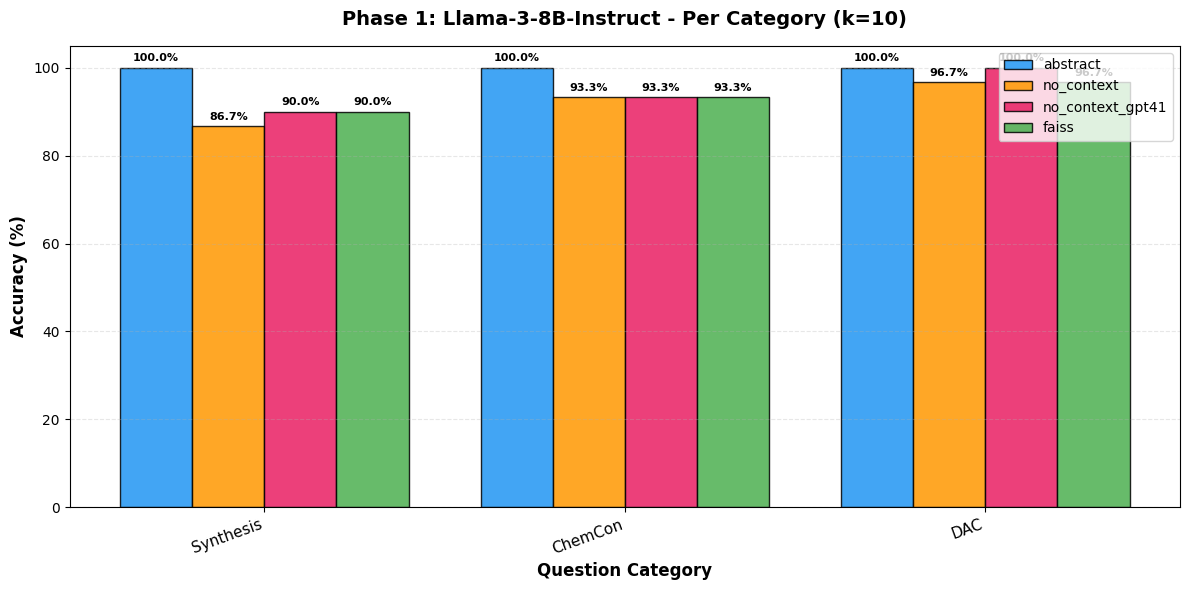

✓ Phase 1 per-category bar chart generated


In [13]:
# Phase 1 Results: Per-category + overall bar charts
import matplotlib.pyplot as plt
import numpy as np

phase1_methods = ['abstract', 'no_context', 'no_context_gpt41', 'faiss']
method_colors = {'abstract': '#2196F3', 'no_context': '#FF9800', 'no_context_gpt41': '#E91E63', 'faiss': '#4CAF50'}

# --- Print summary table ---
print("\n" + "="*90)
print("PHASE 1 RESULTS: Abstract, No Context, FAISS (per category)")
print("="*90)
print(f"{'Category':<15} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*90)
for cat in ALL_CATEGORIES:
    for method in phase1_methods:
        r = all_results[model_display_name]['k=10'][cat][method]
        print(f"{cat:<15} {method:<15} {r['accuracy']:>6.2f}%      {r['correct_count']}/{r['total']}")
    print("-"*90)

# Overall accuracy (sum correct / sum total across categories)
print(f"\n{'OVERALL':<15}", end="")
for method in phase1_methods:
    total_correct = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    total_n = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_acc = (total_correct / total_n * 100) if total_n > 0 else 0
    print(f"  {method}: {overall_acc:.2f}% ({total_correct}/{total_n})", end="")
print()
print("="*90)

# --- Grouped bar chart: 4 categories, 3 methods each ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ALL_CATEGORIES))
bar_width = 0.20

for i, method in enumerate(phase1_methods):
    accs = [all_results[model_display_name]['k=10'][cat][method]['accuracy'] for cat in ALL_CATEGORIES]
    bars = ax.bar(x + i * bar_width, accs, bar_width, label=method, 
                  color=method_colors[method], alpha=0.85, edgecolor='black')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)

ax.set_xlabel('Question Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Phase 1: {model_display_name} - Per Category (k=10)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(ALL_CATEGORIES, rotation=20, ha='right', fontsize=11)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 105)

plt.tight_layout()
fig.savefig(f'phase1_per_category_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()
print("✓ Phase 1 per-category bar chart generated")

## Phase 2: MMR, BM25, Hybrid

Run the remaining four retrieval methods.

In [14]:
# Phase 2 methods
phase2_methods = ['mmr', 'bm25', 'hybrid']

for k in K_VALUES:
    print(f"\n{'='*80}")
    print(f"Running Phase 2 experiments with k={k}")
    print(f"{'='*80}")
    
    for category in ALL_CATEGORIES:
        questions_df = category_dfs[category]
        
        for method in phase2_methods:
            print(f"\n--- {category} | {method.upper()} | k={k} ({len(questions_df)} questions) ---")
            
            try:
                result = evaluate_method(llm, method, questions_df, tokenizer, k=k)
                all_results[model_display_name][f"k={k}"][category][method] = result
                
                print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
                
            except Exception as e:
                print(f"✗ Error: {str(e)}")
                all_results[model_display_name][f"k={k}"][category][method] = {
                    'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
                }
    
    # Save intermediate results (WITH detailed_results for downstream use)
    temp_save_path = f'results_23e_complete_{timestamp}.json'
    with open(temp_save_path, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
    print(f"✓ Intermediate results saved to: {temp_save_path} ({os.path.getsize(temp_save_path)/(1024*1024):.1f} MB)")

print(f"\n{'='*80}")
print(f"Phase 2 complete!")
print(f"{'='*80}")


Running Phase 2 experiments with k=10

--- Synthesis | MMR | k=10 (30 questions) ---


Evaluating mmr (k=10):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxi

✓ 96.67% (29/30)

--- Synthesis | BM25 | k=10 (30 questions) ---


Evaluating bm25 (k=10):   0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_754287/4211051235.py:13: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = bm25_retriever.get_relevant_documents(query)[:k]
/tmp/ipykernel_754287/4211051235.py:13: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = bm25_retriever.get_relevant_documents(query)[:k]
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but i

✓ 86.67% (26/30)

--- Synthesis | HYBRID | k=10 (30 questions) ---


...

Processing error: CUDA out of memory. Tried to allocate 1.67 GiB (GPU 3; 23.55 GiB total capacity; 20.51 GiB already allocated; 485.56 MiB free; 22.21 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

Processing error: CUDA out of memory. Tried to allocate 5.44 GiB (GPU 3; 23.55 GiB total capacity; 18.17 GiB already allocated; 4.47 GiB free; 18.21 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF
✓ 86.67% (26/30)

--- DAC | HYBRID | k=10 (30 questions) ---


Evaluating hybrid (k=10):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m

Processing error: CUDA out of memory. Tried to allocate 1.71 GiB (GPU 3; 23.55 GiB total capacity; 20.62 GiB already allocated; 343.56 MiB free; 22.35 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF
✓ 96.67% (29/30)
✓ Intermediate results saved to: results_23e_complete_20260306_110417.json (8.1 MB)

Phase 2 complete!


## Full Results: All Methods at k=10 (Per Category + Overall)


FULL RESULTS: All 7 Methods at k=10 (per category + overall)
Category        Method          Accuracy     Correct/Total  
----------------------------------------------------------------------------------------------------
Synthesis       abstract        100.00%      30/30
Synthesis       no_context       86.67%      26/30
Synthesis       no_context_gpt41  90.00%      27/30
Synthesis       faiss            90.00%      27/30
Synthesis       mmr              96.67%      29/30
Synthesis       bm25             86.67%      26/30
Synthesis       hybrid           93.33%      28/30
----------------------------------------------------------------------------------------------------
ChemCon         abstract        100.00%      30/30
ChemCon         no_context       93.33%      28/30
ChemCon         no_context_gpt41  93.33%      28/30
ChemCon         faiss            93.33%      28/30
ChemCon         mmr              93.33%      28/30
ChemCon         bm25             96.67%      29/30
ChemCon   

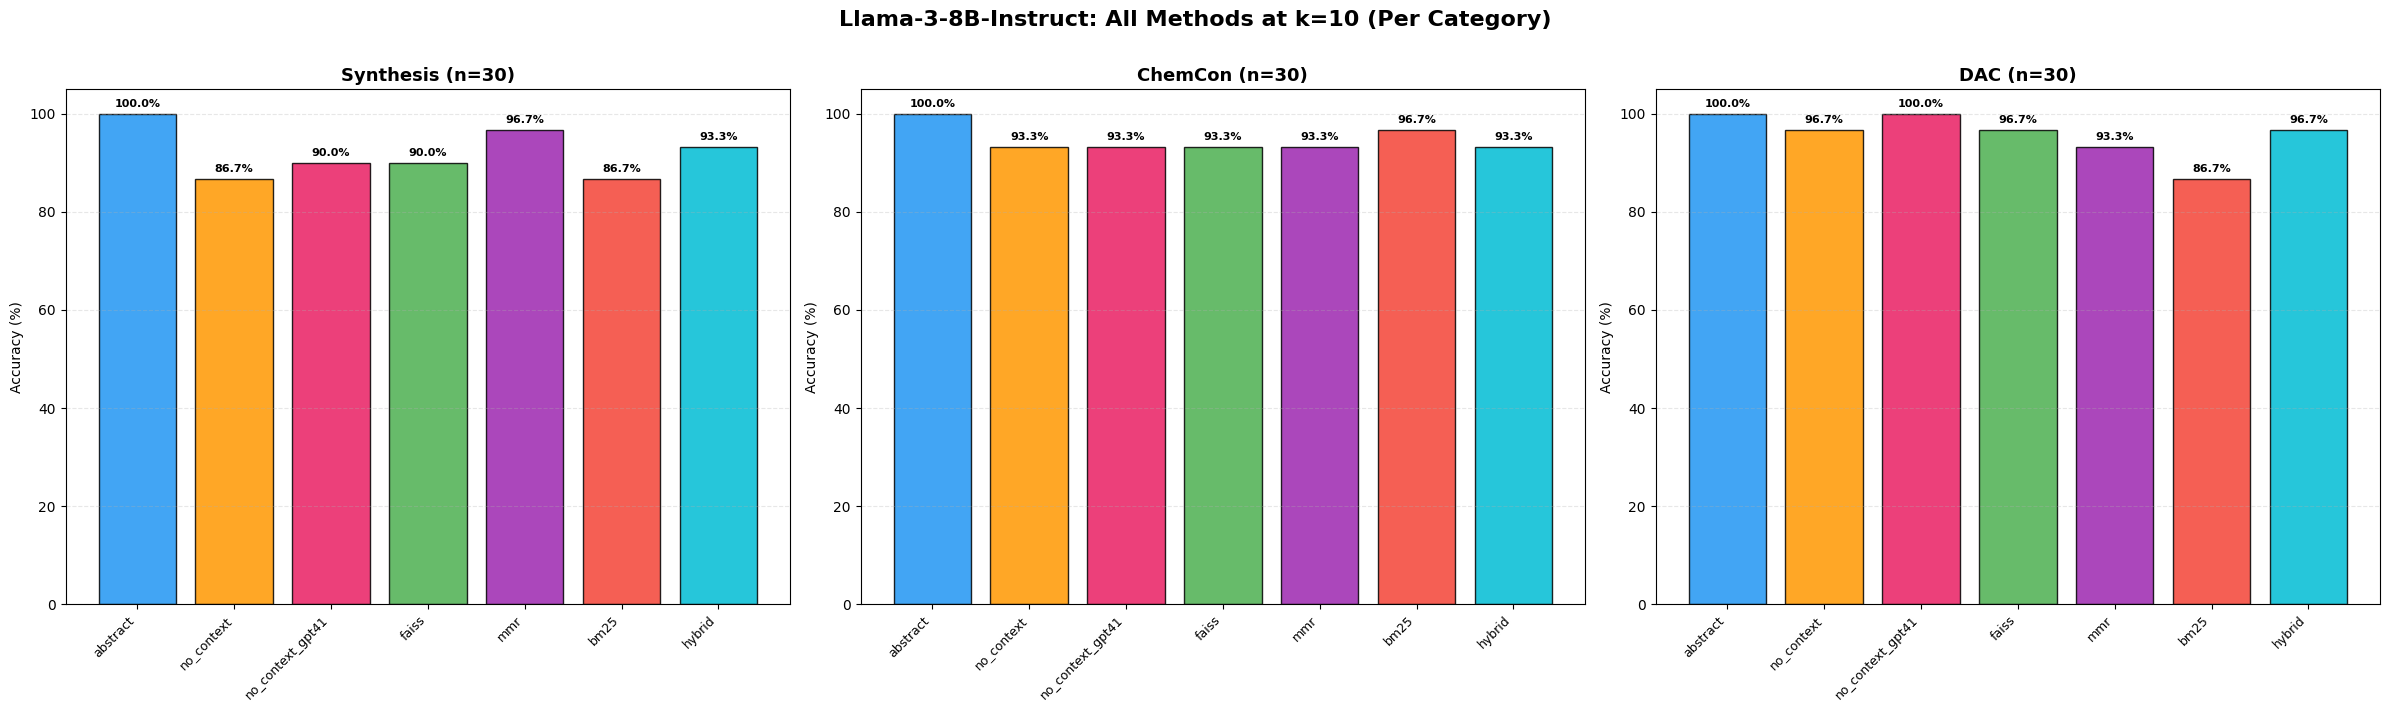

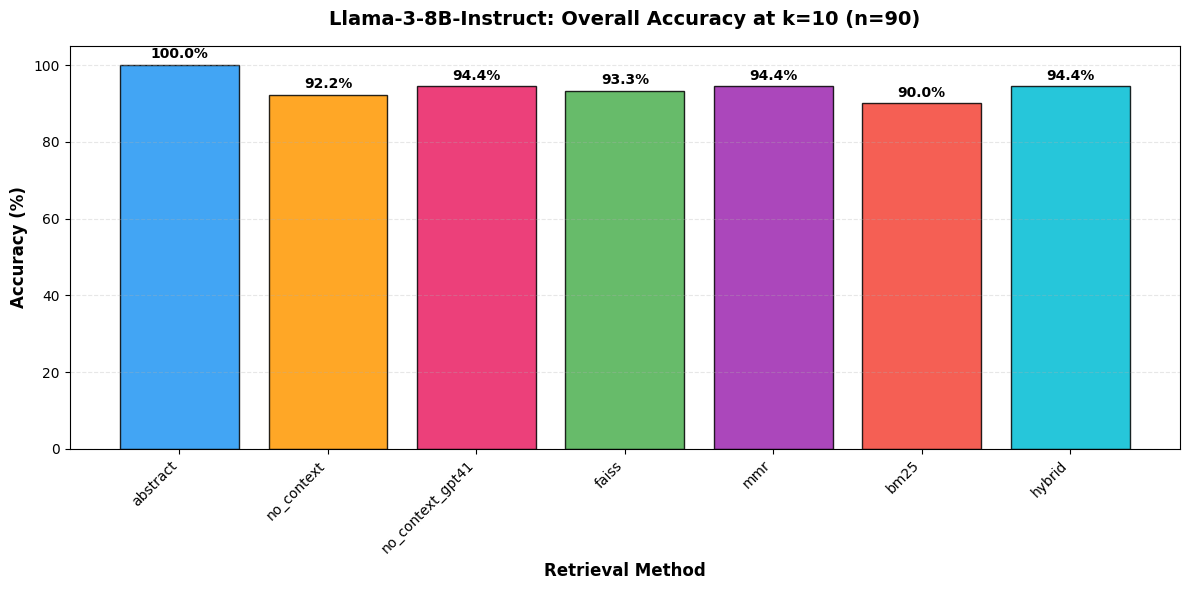

✓ Full results charts generated (per-category + overall)


In [15]:
# Full Results: Per-category + overall bar chart for all 7 methods at k=10
import matplotlib.pyplot as plt
import numpy as np

all_methods_list = ['abstract', 'no_context', 'no_context_gpt41', 'faiss', 'mmr', 'bm25', 'hybrid']
method_colors_all = {
    'abstract': '#2196F3', 'no_context': '#FF9800', 'no_context_gpt41': '#E91E63', 'faiss': '#4CAF50',
    'mmr': '#9C27B0', 'bm25': '#F44336', 'hybrid': '#00BCD4', 'optimized': '#FF5722'
}

# --- Print full summary table ---
print("\n" + "="*100)
print("FULL RESULTS: All 7 Methods at k=10 (per category + overall)")
print("="*100)
print(f"{'Category':<15} {'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*100)

for cat in ALL_CATEGORIES:
    for method in all_methods_list:
        r = all_results[model_display_name]['k=10'][cat][method]
        print(f"{cat:<15} {method:<15} {r['accuracy']:>6.2f}%      {r['correct_count']}/{r['total']}")
    print("-"*100)

# Overall
print(f"\n{'OVERALL':}")
print(f"{'Method':<15} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*50)
for method in all_methods_list:
    total_correct = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    total_n = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_acc = (total_correct / total_n * 100) if total_n > 0 else 0
    print(f"{method:<15} {overall_acc:>6.2f}%      {total_correct}/{total_n}")
print("="*100)

# --- Per-category grouped bar chart: 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for idx, cat in enumerate(ALL_CATEGORIES):
    ax = axes[idx]
    accs = [all_results[model_display_name]['k=10'][cat][m]['accuracy'] for m in all_methods_list]
    colors = [method_colors_all[m] for m in all_methods_list]
    
    x = np.arange(len(all_methods_list))
    bars = ax.bar(x, accs, color=colors, alpha=0.85, edgecolor='black')
    
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    n_q = len(category_dfs[cat])
    ax.set_title(f'{cat} (n={n_q})', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_methods_list, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)

fig.suptitle(f'{model_display_name}: All Methods at k=10 (Per Category)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'full_results_per_category_k10_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()

# --- Overall bar chart ---
fig2, ax2 = plt.subplots(figsize=(12, 6))
overall_accs = []
for method in all_methods_list:
    tc = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    overall_accs.append((tc / tn * 100) if tn > 0 else 0)

x = np.arange(len(all_methods_list))
colors = [method_colors_all[m] for m in all_methods_list]
bars = ax2.bar(x, overall_accs, color=colors, alpha=0.85, edgecolor='black')

for bar, acc in zip(bars, overall_accs):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax2.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'{model_display_name}: Overall Accuracy at k=10 (n=90)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(all_methods_list, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 105)

plt.tight_layout()
fig2.savefig(f'full_results_overall_k10_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()

print("✓ Full results charts generated (per-category + overall)")

In [16]:
# Export k=10 results to CSV (per-category + overall)
export_data = []

for cat in ALL_CATEGORIES:
    for method in all_methods_list:
        r = all_results[model_display_name]['k=10'][cat][method]
        export_data.append({
            'model': model_display_name,
            'k': 10,
            'category': cat,
            'method': method,
            'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0),
            'total': r.get('total', 0)
        })

# Add overall rows
for method in all_methods_list:
    tc = sum(all_results[model_display_name]['k=10'][cat][method]['correct_count'] for cat in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][cat][method]['total'] for cat in ALL_CATEGORIES)
    export_data.append({
        'model': model_display_name,
        'k': 10,
        'category': 'Overall',
        'method': method,
        'accuracy': (tc / tn * 100) if tn > 0 else 0,
        'correct': tc,
        'total': tn
    })

export_df = pd.DataFrame(export_data)
csv_filename = f'results_23e_k10_{timestamp}.csv'
export_df.to_csv(csv_filename, index=False)
print(f"Results exported to CSV: {csv_filename}")
print(f"Total rows: {len(export_df)}")
print(export_df.to_string(index=False))

Results exported to CSV: results_23e_k10_20260306_110417.csv
Total rows: 28
              model  k  category           method   accuracy  correct  total
Llama-3-8B-Instruct 10 Synthesis         abstract 100.000000       30     30
Llama-3-8B-Instruct 10 Synthesis       no_context  86.666667       26     30
Llama-3-8B-Instruct 10 Synthesis no_context_gpt41  90.000000       27     30
Llama-3-8B-Instruct 10 Synthesis            faiss  90.000000       27     30
Llama-3-8B-Instruct 10 Synthesis              mmr  96.666667       29     30
Llama-3-8B-Instruct 10 Synthesis             bm25  86.666667       26     30
Llama-3-8B-Instruct 10 Synthesis           hybrid  93.333333       28     30
Llama-3-8B-Instruct 10   ChemCon         abstract 100.000000       30     30
Llama-3-8B-Instruct 10   ChemCon       no_context  93.333333       28     30
Llama-3-8B-Instruct 10   ChemCon no_context_gpt41  93.333333       28     30
Llama-3-8B-Instruct 10   ChemCon            faiss  93.333333       28     30


## Phase 3: k=15 Evaluation for All Retrieval Methods (Per Category)

Run all 4 retrieval methods (FAISS, MMR, BM25, Hybrid) with k=15 across all 3 categories.
The baselines (abstract and no_context) are k-independent and already computed above.

In [17]:
# Phase 3: Run all retrieval methods with k=15 across all categories
# Note: PYTORCH_CUDA_ALLOC_CONF already set in imports cell (max_split_size_mb:256)

k15_methods = ['faiss', 'mmr', 'bm25', 'hybrid']
k15 = 15

torch.cuda.empty_cache()
gc.collect()
print("Cleared GPU cache before k=15 experiments")

# Initialize k=15 storage
if f"k={k15}" not in all_results[model_display_name]:
    all_results[model_display_name][f"k={k15}"] = {}

print(f"\n{'='*80}")
print(f"Running k=15 experiments across all categories")
print(f"{'='*80}")

for category in ALL_CATEGORIES:
    if category not in all_results[model_display_name][f"k={k15}"]:
        all_results[model_display_name][f"k={k15}"][category] = {}
    
    questions_df = category_dfs[category]
    
    for method in k15_methods:
        print(f"\n--- {category} | {method.upper()} | k={k15} ({len(questions_df)} questions) ---")
        
        torch.cuda.empty_cache()
        
        try:
            # Use evaluate_method which already has per-question cache clearing
            result = evaluate_method(llm, method, questions_df, tokenizer, k=k15)
            all_results[model_display_name][f"k={k15}"][category][method] = result
            
            print(f"✓ {result['accuracy']:.2f}% ({result['correct_count']}/{result['total']})")
            
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            all_results[model_display_name][f"k={k15}"][category][method] = {
                'error': str(e), 'accuracy': 0, 'correct_count': 0, 'total': 0
            }
    
    # Save after each category (WITH detailed_results for downstream use)
    temp_save_path = f'results_23e_complete_{timestamp}.json'
    with open(temp_save_path, 'w') as f:
        json.dump(all_results, f, indent=2, default=str)
    print(f"✓ Intermediate results saved to: {temp_save_path} ({os.path.getsize(temp_save_path)/(1024*1024):.1f} MB)")

print(f"\n{'='*80}")
print(f"k=15 experiments complete!")
print(f"{'='*80}")

Cleared GPU cache before k=15 experiments

Running k=15 experiments across all categories

--- Synthesis | FAISS | k=15 (30 questions) ---


Evaluating faiss (k=15):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to ma

✓ 96.67% (29/30)

--- Synthesis | MMR | k=15 (30 questions) ---


Evaluating mmr (k=15):   0%|          | 0/30 [00:00<?, ?it/s]Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maxi

✓ 96.67% (29/30)

--- Synthesis | BM25 | k=15 (30 questions) ---


...

Processing error: CUDA out of memory. Tried to allocate 3.15 GiB (GPU 3; 23.55 GiB total capacity; 17.06 GiB already allocated; 2.45 GiB free; 20.24 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

Processing error: CUDA out of memory. Tried to allocate 4.84 GiB (GPU 3; 23.55 GiB total capacity; 17.84 GiB already allocated; 4.70 GiB free; 17.99 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF


Using unk_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
Using sep_token, but it is not set yet.
Using pad_token, but it is not set yet.
Using cls_token, but it is not set yet.
Using mask_token, but it is not set yet.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001

Processing error: CUDA out of memory. Tried to allocate 5.12 GiB (GPU 3; 23.55 GiB total capacity; 18.00 GiB already allocated; 4.53 GiB free; 18.16 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF
✓ 86.67% (26/30)
✓ Intermediate results saved to: results_23e_complete_20260306_110417.json (17.7 MB)

k=15 experiments complete!


## Combined Results: k=10 vs k=15 with Baselines (Per Category + Overall)

Per-category grouped bar charts comparing all retrieval methods at k=10 and k=15, alongside the three k-independent baselines (Abstract, No Context Llama, and No Context GPT-4.1).


COMBINED RESULTS: Baselines + k=10 vs k=15 (Per Category + Overall)

--- Synthesis ---
Method          Baseline     k=10         k=15         k10→k15     
------------------------------------------------------------
abstract        100.00%          --           --           --
no_context       86.67%          --           --           --
no_context_gpt41  90.00%          --           --           --
faiss               --        90.00%       96.67%      +6.67%
mmr                 --        96.67%       96.67%      +0.00%
bm25                --        86.67%       90.00%      +3.33%
hybrid              --        93.33%       96.67%      +3.33%

--- ChemCon ---
Method          Baseline     k=10         k=15         k10→k15     
------------------------------------------------------------
abstract        100.00%          --           --           --
no_context       93.33%          --           --           --
no_context_gpt41  93.33%          --           --           --
faiss          

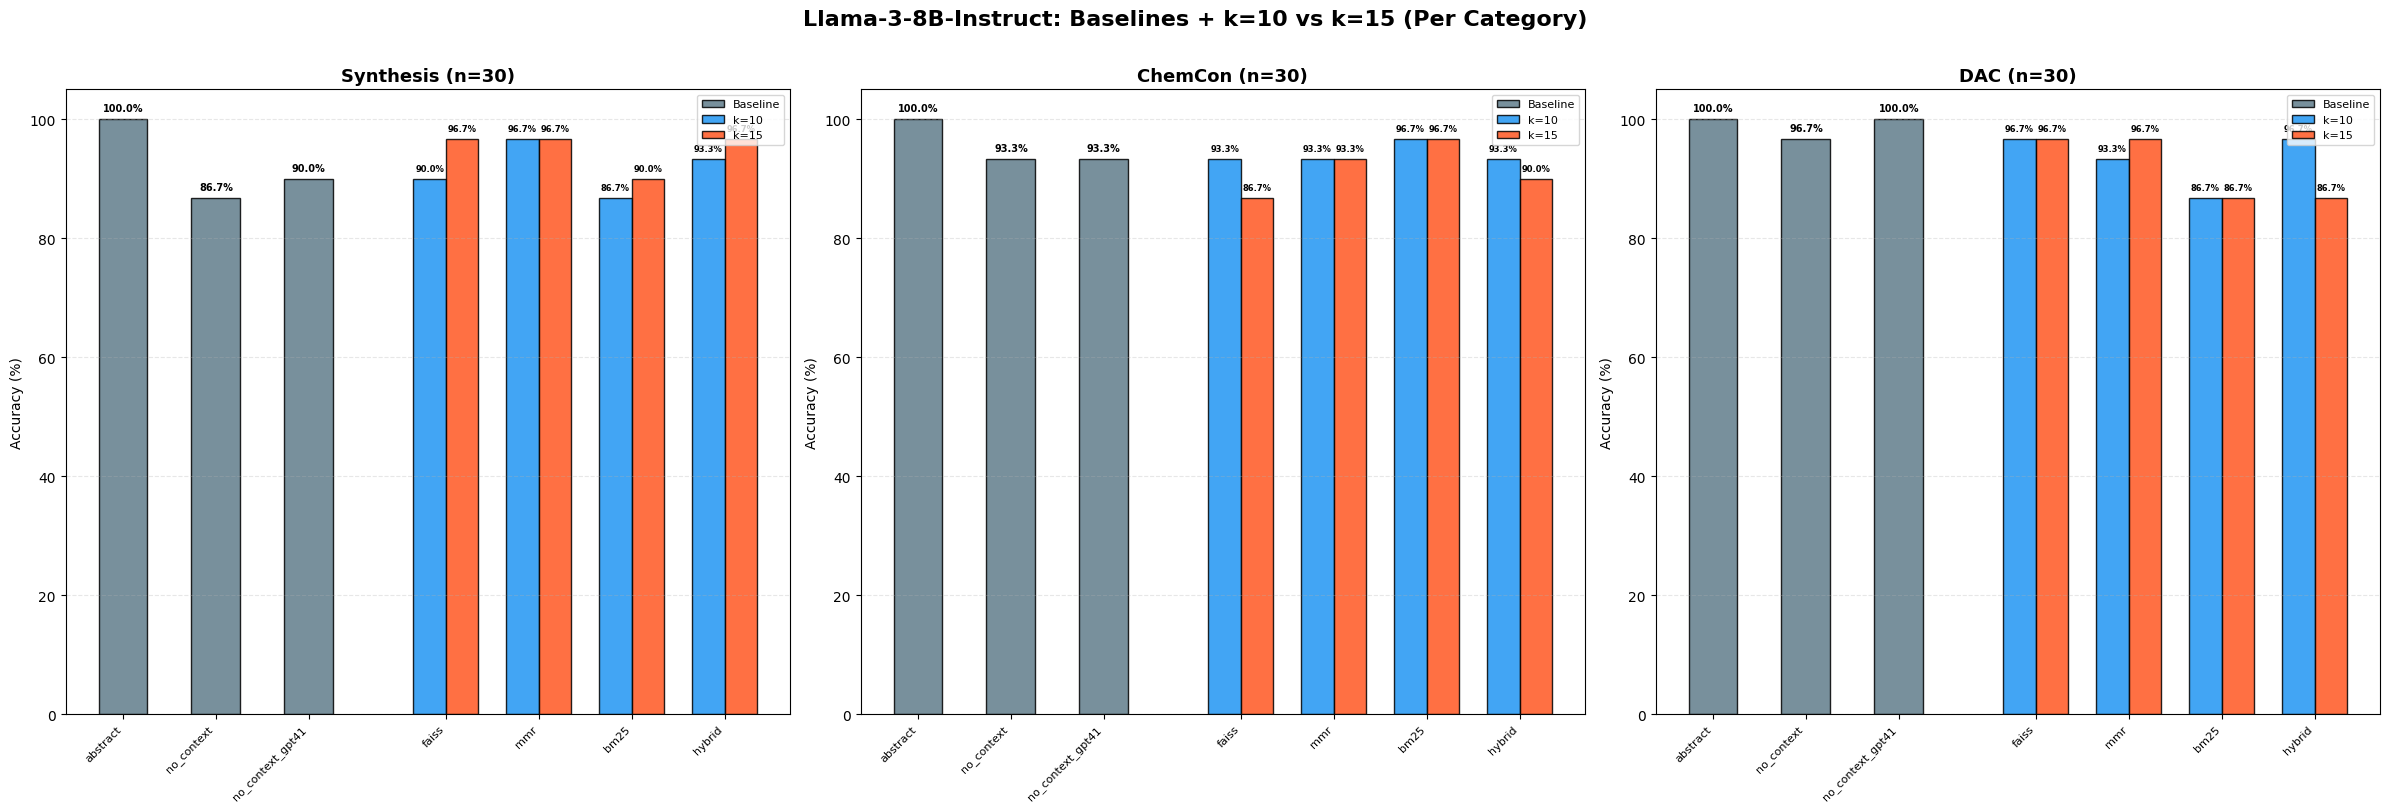

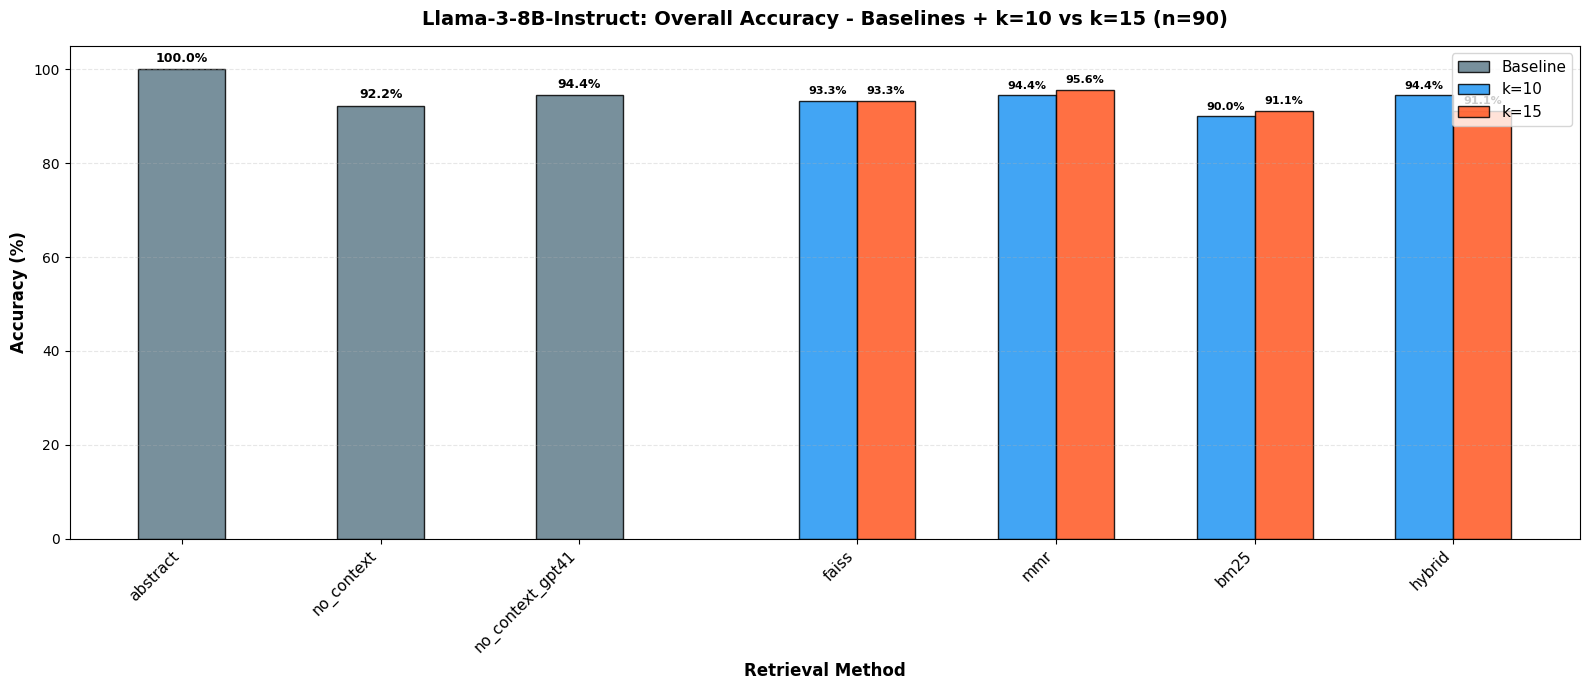

✓ Combined k=10 vs k=15 charts generated (per-category + overall)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

baseline_methods = ['abstract', 'no_context', 'no_context_gpt41']
retrieval_methods = ['faiss', 'mmr', 'bm25', 'hybrid']

# --- Print summary table per category ---
print("\n" + "="*110)
print("COMBINED RESULTS: Baselines + k=10 vs k=15 (Per Category + Overall)")
print("="*110)

for cat in ALL_CATEGORIES + ['Overall']:
    print(f"\n--- {cat} ---")
    print(f"{'Method':<15} {'Baseline':<12} {'k=10':<12} {'k=15':<12} {'k10→k15':<12}")
    print("-"*60)
    
    for m in baseline_methods:
        if cat == 'Overall':
            tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
            acc = (tc / tn * 100) if tn > 0 else 0
        else:
            acc = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        print(f"{m:<15} {acc:>6.2f}%      {'--':>6}       {'--':>6}       {'--':>6}")
    
    for m in retrieval_methods:
        if cat == 'Overall':
            tc10 = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn10 = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
            tc15 = sum(all_results[model_display_name]['k=15'][c][m]['correct_count'] for c in ALL_CATEGORIES)
            tn15 = sum(all_results[model_display_name]['k=15'][c][m]['total'] for c in ALL_CATEGORIES)
            acc10 = (tc10 / tn10 * 100) if tn10 > 0 else 0
            acc15 = (tc15 / tn15 * 100) if tn15 > 0 else 0
        else:
            acc10 = all_results[model_display_name]['k=10'][cat][m]['accuracy']
            acc15 = all_results[model_display_name]['k=15'][cat][m]['accuracy']
        delta = acc15 - acc10
        sign = '+' if delta >= 0 else ''
        print(f"{m:<15} {'--':>6}       {acc10:>6.2f}%      {acc15:>6.2f}%      {sign}{delta:.2f}%")

print("\n" + "="*110)

# --- Per-category grouped bar charts (3 panels) ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, cat in enumerate(ALL_CATEGORIES):
    ax = axes[idx]
    
    bar_width = 0.35
    x_tick_positions = []
    x_tick_labels = []
    current_x = 0
    
    # Baselines (single bars)
    for i, m in enumerate(baseline_methods):
        acc = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        ax.bar(current_x, acc, bar_width * 1.5, color='#607D8B', alpha=0.85, 
               edgecolor='black', label='Baseline' if i == 0 else None)
        ax.text(current_x, acc + 1, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=7)
        x_tick_positions.append(current_x)
        x_tick_labels.append(m)
        current_x += 1.0
    
    current_x += 0.3
    
    # Retrieval methods (paired bars)
    for i, m in enumerate(retrieval_methods):
        x1 = current_x
        x2 = current_x + bar_width
        
        acc10 = all_results[model_display_name]['k=10'][cat][m]['accuracy']
        acc15 = all_results[model_display_name]['k=15'][cat][m]['accuracy']
        
        ax.bar(x1, acc10, bar_width, color='#2196F3', alpha=0.85, edgecolor='black',
               label='k=10' if i == 0 else None)
        ax.bar(x2, acc15, bar_width, color='#FF5722', alpha=0.85, edgecolor='black',
               label='k=15' if i == 0 else None)
        
        ax.text(x1, acc10 + 1, f'{acc10:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=6)
        ax.text(x2, acc15 + 1, f'{acc15:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=6)
        
        x_tick_positions.append((x1 + x2) / 2)
        x_tick_labels.append(m)
        current_x += 1.0
    
    n_q = len(category_dfs[cat])
    ax.set_title(f'{cat} (n={n_q})', fontsize=13, fontweight='bold')
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(loc='upper right', fontsize=8, frameon=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)

fig.suptitle(f'{model_display_name}: Baselines + k=10 vs k=15 (Per Category)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'combined_per_category_k10_k15_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()

# --- Overall bar chart ---
fig2, ax2 = plt.subplots(figsize=(16, 7))

bar_width = 0.35
x_tick_positions = []
x_tick_labels = []
current_x = 0

for i, m in enumerate(baseline_methods):
    tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    acc = (tc / tn * 100) if tn > 0 else 0
    ax2.bar(current_x, acc, bar_width * 1.5, color='#607D8B', alpha=0.85, edgecolor='black',
            label='Baseline' if i == 0 else None)
    ax2.text(current_x, acc + 1, f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    x_tick_positions.append(current_x)
    x_tick_labels.append(m)
    current_x += 1.2

current_x += 0.3

for i, m in enumerate(retrieval_methods):
    x1 = current_x
    x2 = current_x + bar_width
    
    tc10 = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn10 = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    tc15 = sum(all_results[model_display_name]['k=15'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn15 = sum(all_results[model_display_name]['k=15'][c][m]['total'] for c in ALL_CATEGORIES)
    acc10 = (tc10 / tn10 * 100) if tn10 > 0 else 0
    acc15 = (tc15 / tn15 * 100) if tn15 > 0 else 0
    
    ax2.bar(x1, acc10, bar_width, color='#2196F3', alpha=0.85, edgecolor='black',
            label='k=10' if i == 0 else None)
    ax2.bar(x2, acc15, bar_width, color='#FF5722', alpha=0.85, edgecolor='black',
            label='k=15' if i == 0 else None)
    
    ax2.text(x1, acc10 + 1, f'{acc10:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    ax2.text(x2, acc15 + 1, f'{acc15:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    x_tick_positions.append((x1 + x2) / 2)
    x_tick_labels.append(m)
    current_x += 1.2

ax2.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'{model_display_name}: Overall Accuracy - Baselines + k=10 vs k=15 (n=90)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_tick_positions)
ax2.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=11)
ax2.legend(loc='upper right', frameon=True, fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 105)

plt.tight_layout()
fig2.savefig(f'combined_overall_k10_k15_{timestamp}.svg', format='svg', bbox_inches='tight')
plt.show()

print("✓ Combined k=10 vs k=15 charts generated (per-category + overall)")

In [19]:
# Export combined k=10 and k=15 results to CSV (per-category + overall)
combined_data = []

for cat in ALL_CATEGORIES:
    # Baselines (k-independent)
    for m in baseline_methods:
        r = all_results[model_display_name]['k=10'][cat][m]
        combined_data.append({
            'model': model_display_name, 'k': 'baseline', 'category': cat,
            'method': m, 'accuracy': r.get('accuracy', 0),
            'correct': r.get('correct_count', 0), 'total': r.get('total', 0)
        })
    # Retrieval methods at k=10 and k=15
    for k_val in [10, 15]:
        for m in retrieval_methods:
            r = all_results[model_display_name][f'k={k_val}'][cat][m]
            combined_data.append({
                'model': model_display_name, 'k': k_val, 'category': cat,
                'method': m, 'accuracy': r.get('accuracy', 0),
                'correct': r.get('correct_count', 0), 'total': r.get('total', 0)
            })

# Overall rows
for m in baseline_methods:
    tc = sum(all_results[model_display_name]['k=10'][c][m]['correct_count'] for c in ALL_CATEGORIES)
    tn = sum(all_results[model_display_name]['k=10'][c][m]['total'] for c in ALL_CATEGORIES)
    combined_data.append({
        'model': model_display_name, 'k': 'baseline', 'category': 'Overall',
        'method': m, 'accuracy': (tc / tn * 100) if tn > 0 else 0,
        'correct': tc, 'total': tn
    })

for k_val in [10, 15]:
    for m in retrieval_methods:
        tc = sum(all_results[model_display_name][f'k={k_val}'][c][m]['correct_count'] for c in ALL_CATEGORIES)
        tn = sum(all_results[model_display_name][f'k={k_val}'][c][m]['total'] for c in ALL_CATEGORIES)
        combined_data.append({
            'model': model_display_name, 'k': k_val, 'category': 'Overall',
            'method': m, 'accuracy': (tc / tn * 100) if tn > 0 else 0,
            'correct': tc, 'total': tn
        })

combined_df = pd.DataFrame(combined_data)
combined_csv = f'results_23e_k10_k15_combined_{timestamp}.csv'
combined_df.to_csv(combined_csv, index=False)
print(f"Combined results exported to CSV: {combined_csv}")
print(f"\nTotal rows: {len(combined_df)}")
print(combined_df.to_string(index=False))

Combined results exported to CSV: results_23e_k10_k15_combined_20260306_110417.csv

Total rows: 44
              model        k  category           method   accuracy  correct  total
Llama-3-8B-Instruct baseline Synthesis         abstract 100.000000       30     30
Llama-3-8B-Instruct baseline Synthesis       no_context  86.666667       26     30
Llama-3-8B-Instruct baseline Synthesis no_context_gpt41  90.000000       27     30
Llama-3-8B-Instruct       10 Synthesis            faiss  90.000000       27     30
Llama-3-8B-Instruct       10 Synthesis              mmr  96.666667       29     30
Llama-3-8B-Instruct       10 Synthesis             bm25  86.666667       26     30
Llama-3-8B-Instruct       10 Synthesis           hybrid  93.333333       28     30
Llama-3-8B-Instruct       15 Synthesis            faiss  96.666667       29     30
Llama-3-8B-Instruct       15 Synthesis              mmr  96.666667       29     30
Llama-3-8B-Instruct       15 Synthesis             bm25  90.000000     

In [20]:
# Error analysis: k=10 correct → k=15 wrong (per category)
retrieval_methods_to_check = ['faiss', 'mmr', 'bm25', 'hybrid']

print("="*110)
print("ERROR ANALYSIS: Questions where k=10 was CORRECT but k=15 was WRONG (per category)")
print("="*110)

total_regressions = 0

for cat in ALL_CATEGORIES:
    print(f"\n{'#'*110}")
    print(f"CATEGORY: {cat} ({len(category_dfs[cat])} questions)")
    print(f"{'#'*110}")
    
    for method in retrieval_methods_to_check:
        k10_detailed = all_results[model_display_name]['k=10'][cat][method].get('detailed_results', [])
        k15_detailed = all_results[model_display_name]['k=15'][cat][method].get('detailed_results', [])
        
        if not k10_detailed or not k15_detailed:
            print(f"\n{method.upper()}: No detailed results available")
            continue
        
        regressions = []
        for i, (r10, r15) in enumerate(zip(k10_detailed, k15_detailed)):
            if r10.get('is_correct', False) and not r15.get('is_correct', False):
                regressions.append((i, r10, r15))
        
        if not regressions:
            print(f"\n{method.upper()}: No regressions")
            continue
        
        total_regressions += len(regressions)
        print(f"\n{method.upper()}: {len(regressions)} regression(s)")
        
        for idx, r10, r15 in regressions:
            print(f"  Q#{idx+1}: Correct={r10.get('correct_answer','?')} | "
                  f"k10={r10.get('model_answer','?')} ✓ | k15={r15.get('model_answer','?')} ✗")

print(f"\n{'='*110}")
print(f"TOTAL REGRESSIONS: {total_regressions}")
print(f"{'='*110}")

# Compact summary table
print(f"\n{'Category':<15} {'Method':<15} {'k=10 Acc':<12} {'k=15 Acc':<12} {'Regr.':<10} {'Impr.':<10}")
print("-"*75)
for cat in ALL_CATEGORIES:
    for method in retrieval_methods_to_check:
        k10_d = all_results[model_display_name]['k=10'][cat][method].get('detailed_results', [])
        k15_d = all_results[model_display_name]['k=15'][cat][method].get('detailed_results', [])
        
        regressions = sum(1 for r10, r15 in zip(k10_d, k15_d) 
                          if r10.get('is_correct') and not r15.get('is_correct'))
        improvements = sum(1 for r10, r15 in zip(k10_d, k15_d) 
                           if not r10.get('is_correct') and r15.get('is_correct'))
        
        k10_acc = all_results[model_display_name]['k=10'][cat][method]['accuracy']
        k15_acc = all_results[model_display_name]['k=15'][cat][method]['accuracy']
        
        print(f"{cat:<15} {method:<15} {k10_acc:>6.2f}%      {k15_acc:>6.2f}%      {regressions:<10} {improvements:<10}")
    print("-"*75)

ERROR ANALYSIS: Questions where k=10 was CORRECT but k=15 was WRONG (per category)

##############################################################################################################
CATEGORY: Synthesis (30 questions)
##############################################################################################################

FAISS: No regressions

MMR: No regressions

BM25: No regressions

HYBRID: No regressions

##############################################################################################################
CATEGORY: ChemCon (30 questions)
##############################################################################################################

FAISS: 2 regression(s)
  Q#3: Correct=A | k10=A ✓ | k15=INVALID ✗
  Q#5: Correct=C | k10=C ✓ | k15=E ✗

MMR: No regressions

BM25: No regressions

HYBRID: 1 regression(s)
  Q#3: Correct=A | k10=A ✓ | k15=INVALID ✗

#################################################################################################

In [21]:
# INVALID / ERROR / OOM Summary: Count non-valid answers per k, method, category
# An answer is "invalid" if model_answer is 'INVALID' or 'ERROR' (i.e., not A-E)
all_methods_check = ['abstract', 'no_context', 'no_context_gpt41', 'faiss', 'mmr', 'bm25', 'hybrid']
k_labels_to_check = ['k=10', 'k=15']

# For baselines, only k=10 has results (they are k-independent)
baseline_set = {'abstract', 'no_context', 'no_context_gpt41'}

print("="*120)
print("INVALID / ERROR / OOM ANSWER SUMMARY")
print("Counts questions where the model returned INVALID or ERROR instead of A-E")
print("="*120)

grand_total_invalid = 0
grand_total_questions = 0

print(f"\n{'Category':<15} {'Method':<15} {'k':<8} {'Total Q':<10} {'Invalid':<10} {'Errors':<10} {'Valid %':<10}")
print("-"*80)

for cat in ALL_CATEGORIES:
    for method in all_methods_check:
        for k_label in k_labels_to_check:
            # Baselines only exist under k=10
            if method in baseline_set and k_label != 'k=10':
                continue
            # Retrieval methods at k=15 only
            if method not in baseline_set and k_label == 'k=10':
                pass  # k=10 exists for all retrieval methods
            
            result = all_results.get(model_display_name, {}).get(k_label, {}).get(cat, {}).get(method, {})
            detailed = result.get('detailed_results', [])
            
            if not detailed:
                continue
            
            total_q = len(detailed)
            # Count INVALID answers (parser couldn't extract A-E)
            n_invalid = sum(1 for r in detailed if r.get('model_answer') == 'INVALID')
            # Count ERROR answers (OOM or other runtime exceptions)
            n_error = sum(1 for r in detailed if r.get('model_answer') == 'ERROR')
            n_bad = n_invalid + n_error
            valid_pct = ((total_q - n_bad) / total_q * 100) if total_q > 0 else 0
            
            grand_total_invalid += n_bad
            grand_total_questions += total_q
            
            if n_bad > 0:
                print(f"{cat:<15} {method:<15} {k_label:<8} {total_q:<10} {n_invalid:<10} {n_error:<10} {valid_pct:>6.1f}%  ⚠")
            else:
                print(f"{cat:<15} {method:<15} {k_label:<8} {total_q:<10} {n_invalid:<10} {n_error:<10} {valid_pct:>6.1f}%")

print("-"*80)

# Overall summary
overall_valid_pct = ((grand_total_questions - grand_total_invalid) / grand_total_questions * 100) if grand_total_questions > 0 else 0
print(f"\n{'GRAND TOTAL':<30} {grand_total_questions:<10} {grand_total_invalid} invalid/error out of {grand_total_questions} ({overall_valid_pct:.1f}% valid)")

# Per-k summary
print(f"\n{'--- Per-k totals ---':}")
for k_label in k_labels_to_check:
    k_total = 0
    k_invalid = 0
    k_error = 0
    for cat in ALL_CATEGORIES:
        for method in all_methods_check:
            if method in baseline_set and k_label != 'k=10':
                continue
            detailed = all_results.get(model_display_name, {}).get(k_label, {}).get(cat, {}).get(method, {}).get('detailed_results', [])
            k_total += len(detailed)
            k_invalid += sum(1 for r in detailed if r.get('model_answer') == 'INVALID')
            k_error += sum(1 for r in detailed if r.get('model_answer') == 'ERROR')
    k_bad = k_invalid + k_error
    k_valid_pct = ((k_total - k_bad) / k_total * 100) if k_total > 0 else 0
    print(f"  {k_label}: {k_bad} invalid/error out of {k_total} questions ({k_valid_pct:.1f}% valid) — {k_invalid} INVALID, {k_error} ERROR/OOM")

print("\n" + "="*120)

INVALID / ERROR / OOM ANSWER SUMMARY
Counts questions where the model returned INVALID or ERROR instead of A-E

Category        Method          k        Total Q    Invalid    Errors     Valid %   
--------------------------------------------------------------------------------
Synthesis       abstract        k=10     30         0          0           100.0%
Synthesis       no_context      k=10     30         0          0           100.0%
Synthesis       no_context_gpt41 k=10     30         0          0           100.0%
Synthesis       faiss           k=10     30         0          0           100.0%
Synthesis       faiss           k=15     30         0          0           100.0%
Synthesis       mmr             k=10     30         0          0           100.0%
Synthesis       mmr             k=15     30         0          0           100.0%
Synthesis       bm25            k=10     30         0          0           100.0%
Synthesis       bm25            k=15     30         0          0 

## Save Complete Results (with detailed_results)

Save the full `all_results` dictionary **including per-question `detailed_results`** (queries, contexts, model responses, explanations).  
This file is needed by downstream notebooks like **Mrigi 30 LLM-as-Judge**.

> **Note:** The intermediate saves above also include `detailed_results`. This is a final save with a fresh timestamp.

In [22]:
# ============================================================
# Save COMPLETE results WITH detailed_results for downstream use
# (Mrigi 30 LLM-as-Judge, etc.)
# ============================================================
import json, os
from datetime import datetime

save_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
complete_save_path = f'results_23e_complete_{save_timestamp}.json'

# Save the full all_results dict (including detailed_results with per-question data)
with open(complete_save_path, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

size_mb = os.path.getsize(complete_save_path) / (1024 * 1024)
print(f"✓ Complete results saved to: {complete_save_path}")
print(f"  File size: {size_mb:.1f} MB")

# Verify detailed_results are present
model_name = list(all_results.keys())[0]
first_k = list(all_results[model_name].keys())[0]
first_cat = list(all_results[model_name][first_k].keys())[0]
first_method = list(all_results[model_name][first_k][first_cat].keys())[0]
sample = all_results[model_name][first_k][first_cat][first_method]

has_detailed = 'detailed_results' in sample
print(f"  Has detailed_results: {has_detailed}")
if has_detailed:
    n_questions = len(sample['detailed_results'])
    sample_keys = list(sample['detailed_results'][0].keys())
    print(f"  Sample entry keys: {sample_keys}")
    print(f"  Questions in first method: {n_questions}")

# Count total questions saved
total_saved = 0
for mn in all_results:
    for kl in all_results[mn]:
        for cat in all_results[mn][kl]:
            for meth in all_results[mn][kl][cat]:
                dr = all_results[mn][kl][cat][meth].get('detailed_results', [])
                total_saved += len(dr)
print(f"\n  Total question-level records saved: {total_saved}")
print(f"\n⚡ This file can be loaded by Mrigi 30 or other downstream notebooks.")

✓ Complete results saved to: results_23e_complete_20260306_151841.json
  File size: 17.7 MB
  Has detailed_results: True
  Sample entry keys: ['query', 'context', 'model_answer', 'correct_answer', 'is_correct', 'full_response', 'explanation']
  Questions in first method: 30

  Total question-level records saved: 990

⚡ This file can be loaded by Mrigi 30 or other downstream notebooks.
